# Handling Imbalanced & Messy Real-World Data

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
plt.rcParams['figure.figsize'] = (10, 6)

## 1. Load Data

In [31]:
fraud_data = pd.read_csv("../data/creditcard.csv")
fraud_data

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


## 2. Display Top-5 rows

In [32]:
fraud_data.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 3. Display Bottom-5 rows

In [33]:
fraud_data.tail()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0
284806,172792.0,-0.533413,-0.189733,0.703337,-0.506271,-0.012546,-0.649617,1.577006,-0.414650,0.486180,...,0.261057,0.643078,0.376777,0.008797,-0.473649,-0.818267,-0.002415,0.013649,217.00,0


## 4. Check the shape of the dataset 

In [34]:
overall_shape = fraud_data.shape
print(f"No.of rows: {overall_shape[0]}")
print(f"No.of cols: {overall_shape[1]}")

No.of rows: 284807
No.of cols: 31


## 5. Get overall information about the dataset

In [35]:
fraud_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

## 6. Get the overall statistics about the dataset

In [36]:
fraud_data.describe().T

,count,mean,std,min,25%,50%,75%,max
Time,284807.0,9.481386e+04,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000
V1,284807.0,1.175161e-15,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.0,3.384974e-16,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.0,-1.379537e-15,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.0,2.094852e-15,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
V5,284807.0,1.021879e-15,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666
V6,284807.0,1.494498e-15,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626
V7,284807.0,-5.620335e-16,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494
V8,284807.0,1.149614e-16,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208
V9,284807.0,-2.414189e-15,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995


## 7. Check the missing values

In [37]:
fraud_data.isnull().sum().sum()

np.int64(0)

## 8. Identifying Duplicates

In [38]:
duplicate_count = fraud_data.duplicated().sum()
print(f"Duplicate rows: {duplicate_count}")

Duplicate rows: 1081


## 9. Checking Class `Target` variable Distribution

In [39]:
print(f"\nClass distribution:\n{fraud_data['Class'].value_counts()}")
print(f"\nClass proportions:\n{fraud_data['Class'].value_counts(normalize=True)*100}")


Class distribution:
Class
0    284315
1       492
Name: count, dtype: int64

Class proportions:
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


## 10. Visualizing Imbalance

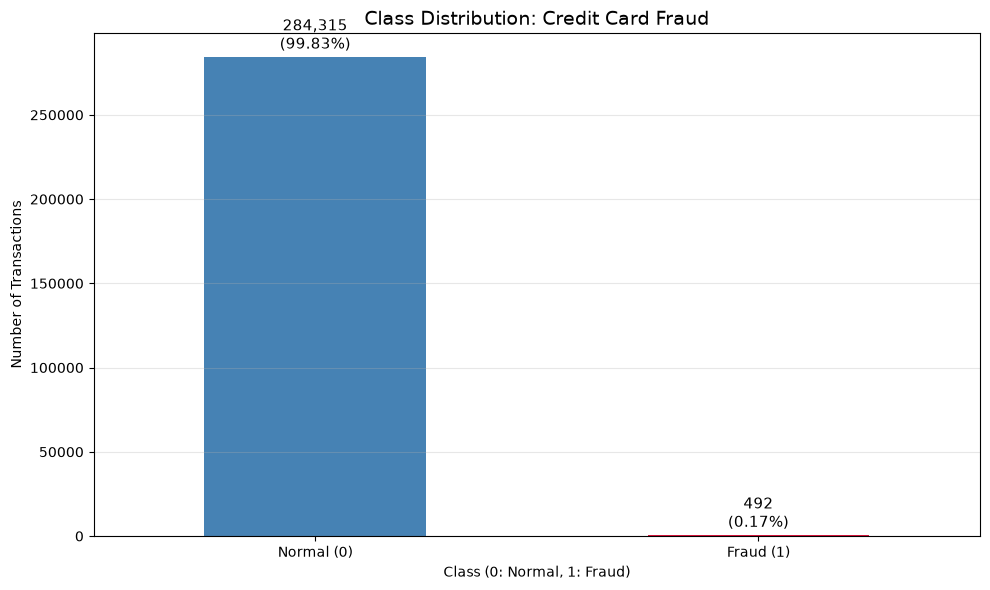

In [40]:
counts = fraud_data['Class'].value_counts()
colors = ['steelblue', 'crimson']
counts.plot(kind='bar', color=colors)
plt.title('Class Distribution: Credit Card Fraud', fontsize=14)
plt.xlabel('Class (0: Normal, 1: Fraud)')
plt.ylabel('Number of Transactions')
plt.xticks([0, 1], ['Normal (0)', 'Fraud (1)'], rotation=0)
plt.grid(axis='y', alpha=0.3)

# Add percentage labels on bars
for i, v in enumerate(counts):
    pct = (v / counts.sum()) * 100
    plt.text(i, v + 5000, f"{v:,}\n({pct:.2f}%)", ha='center', fontsize=11)

plt.tight_layout()
plt.show()

## 11. Outlier Detection

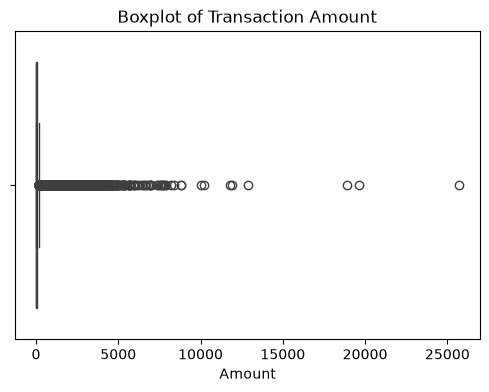

In [41]:
plt.figure(figsize=(6,4))
sns.boxplot(x=fraud_data['Amount'])
plt.title('Boxplot of Transaction Amount')
plt.show()

In [42]:
fraud_data['Amount'].describe()

count    284807.000000
mean         88.349619
std         250.120109
min           0.000000
25%           5.600000
50%          22.000000
75%          77.165000
max       25691.160000
Name: Amount, dtype: float64

### Interpretation
- Amount has significant outliers: most transactions are small, but a handful are very large (see boxplot). We keep them as is rather than removing them, since large transactions could genuinely be more likely to be fraud, not just noisy data — removing them could throw away exactly the pattern we want to detect.

## 12. Amount by Fraud

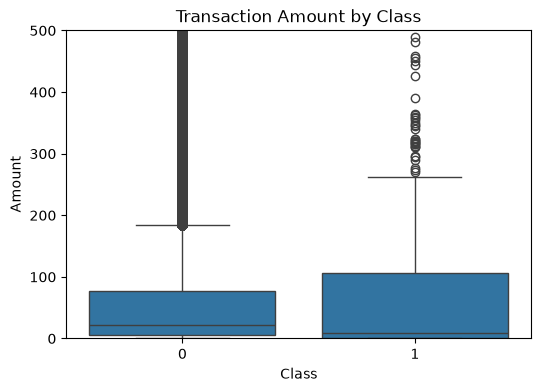

In [43]:
plt.figure(figsize=(6,4))
sns.boxplot(x='Class', y='Amount', data=fraud_data)
plt.title('Transaction Amount by Class')
plt.ylim(0, 500)   # zoom in, since extreme outliers otherwise crush the plot
plt.show()

## 13. Time Pattern Check 

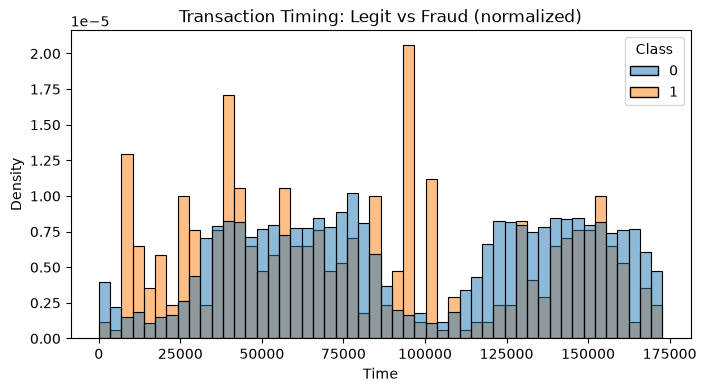

In [44]:
plt.figure(figsize=(8,4))
sns.histplot(data=fraud_data, x='Time', hue='Class', bins=50, stat='density', common_norm=False)
plt.title('Transaction Timing: Legit vs Fraud (normalized)')
plt.show()

## 14. Fraud Rate by Hours

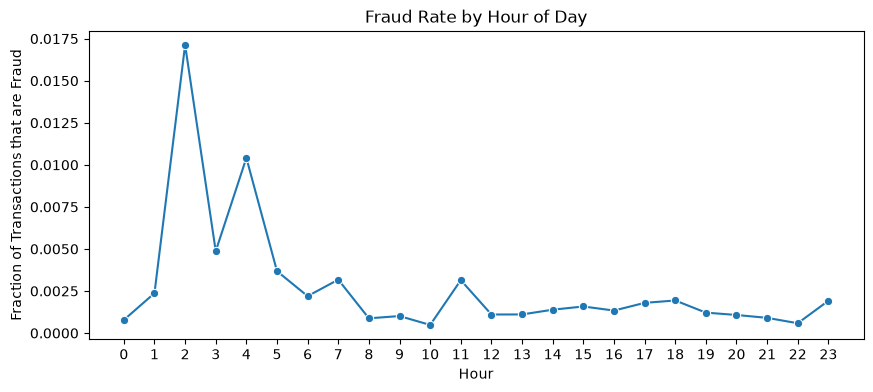

In [45]:
fraud_data['Hour'] = ((fraud_data['Time'] / 3600) % 24).astype(int)

plt.figure(figsize=(10,4))
hourly_fraud_rate = fraud_data.groupby('Hour')['Class'].mean()
sns.lineplot(x=hourly_fraud_rate.index, y=hourly_fraud_rate.values, marker='o')
plt.title('Fraud Rate by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('Fraction of Transactions that are Fraud')
plt.xticks(range(0, 24))
plt.show()

## 15. Correlation

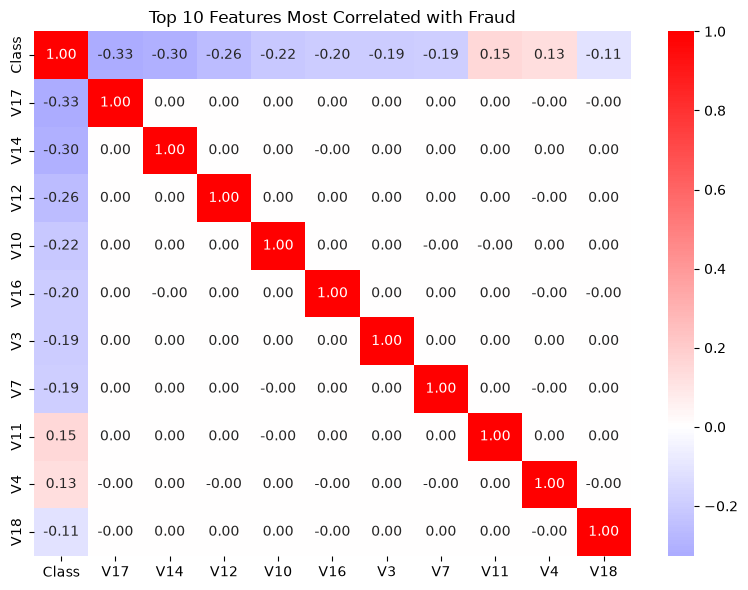

In [46]:
top_corr_features = fraud_data.corr()['Class'].abs().sort_values(ascending=False).head(11).index

plt.figure(figsize=(8,6))
sns.heatmap(fraud_data[top_corr_features].corr(), annot=True, fmt='.2f', cmap='bwr', center=0)
plt.title('Top 10 Features Most Correlated with Fraud')
plt.tight_layout()
plt.show()

### EDA Summary
- The dataset is clean (no missing values) but had ~1,081 duplicate rows, which can be removed in future. 
- It is extremely imbalanced — fraud makes up only about 0.17% of transactions after cleaning. 
- `Amount` has real outliers on the high end, but keep them since unusually large 
transactions may genuinely correlate with fraud rather than being data errors. 
- Most features (`V1`-`V28`) are anonymized PCA components, so interpretability is limited beyond correlation 
strength. 
- Given the severe imbalance, accuracy alone will not be a meaningful metric going 
forward — precision, recall, and F1 on the fraud class will matter far more.

## Data Cleaning

### 1. Remove Duplicates

In [47]:
fraud_data = fraud_data.drop_duplicates()
print(f"Total rows dropped: {overall_shape[0]- fraud_data.shape[0]}")

Total rows dropped: 1081


In [48]:
print(f"Shape of the data after dropping duplicate rows: {fraud_data.shape}")

Shape of the data after dropping duplicate rows: (283726, 32)


### 2. Dropping the `Hour` helper column

In [49]:
fraud_data = fraud_data.drop(columns=['Hour'])

### 3. Split features/target and train/test split

In [50]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, precision_score, recall_score, f1_score,
    accuracy_score, ConfusionMatrixDisplay,
    average_precision_score, roc_auc_score, precision_recall_curve
)
from imblearn.over_sampling import SMOTE
from collections import Counter

#### 3.1 Defining Inputs and Ouput

In [51]:
X = fraud_data.drop(columns=['Class'])
y = fraud_data['Class']

#### 3.2 Train-Test split

In [52]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

scaler = StandardScaler()
X_train[['Time', 'Amount']] = scaler.fit_transform(X_train[['Time', 'Amount']])
X_test[['Time', 'Amount']] = scaler.transform(X_test[['Time', 'Amount']])

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Train class dist: {(Counter(y_train))}")

Train: (226980, 30), Test: (56746, 30)
Train class dist: Counter({0: 226602, 1: 378})


### 4. Train baseline model (Without Balancing)

In [53]:
model_before = LogisticRegression(max_iter=1000, random_state=42)
model_before.fit(X_train, y_train)

y_pred_before = model_before.predict(X_test)
y_prob_before = model_before.predict_proba(X_test)[:, 1]

### 5. Calculating Metrics

In [54]:
def get_metrics(y_true, y_pred, label):
    return {
        'Approach': label,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'F1': f1_score(y_true, y_pred, zero_division=0)
    }

metrics_before = get_metrics(y_test, y_pred_before, 'Before (Imbalanced)')
metrics_before['ROC-AUC'] = roc_auc_score(y_test, y_prob_before)
metrics_before['PR-AUC'] = average_precision_score(y_test, y_prob_before)

print(pd.DataFrame([metrics_before]).round(4))
print("\nClassification Report (Before):")
print(classification_report(y_test, y_pred_before, target_names=['Normal', 'Fraud']))

              Approach  Accuracy  Precision  Recall      F1  ROC-AUC  PR-AUC
0  Before (Imbalanced)    0.9991     0.8485  0.5895  0.6957   0.9563  0.6923

Classification Report (Before):
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56651
       Fraud       0.85      0.59      0.70        95

    accuracy                           1.00     56746
   macro avg       0.92      0.79      0.85     56746
weighted avg       1.00      1.00      1.00     56746



### 6. Applying SMOTE (On Training Data)

SMOTE creates synthetic minority-class (fraud) examples by interpolating between existing fraud cases, rather than duplicating them. Applied only to the training set — the test set is untouched, so it still reflects the real-world imbalance, keeping evaluation honest.

In [55]:
print(f"Before SMOTE: {Counter(y_train)}")

smote = SMOTE(sampling_strategy=0.1, random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"After SMOTE:  {Counter(y_train_smote)}")

Before SMOTE: Counter({0: 226602, 1: 378})
After SMOTE:  Counter({0: 226602, 1: 22660})


### 7. Train AFTER Balancing

In [56]:
model_after = LogisticRegression(max_iter=1000, random_state=42)
model_after.fit(X_train_smote, y_train_smote)

y_pred_after = model_after.predict(X_test)
y_prob_after = model_after.predict_proba(X_test)[:, 1]

metrics_after = get_metrics(y_test, y_pred_after, 'After SMOTE')
metrics_after['ROC-AUC'] = roc_auc_score(y_test, y_prob_after)
metrics_after['PR-AUC'] = average_precision_score(y_test, y_prob_after)

print(pd.DataFrame([metrics_after]).round(4))
print("\nClassification Report (After):")
print(classification_report(y_test, y_pred_after, target_names=['Normal', 'Fraud']))

      Approach  Accuracy  Precision  Recall      F1  ROC-AUC  PR-AUC
0  After SMOTE    0.9978     0.4153     0.8  0.5468    0.967  0.6912

Classification Report (After):
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56651
       Fraud       0.42      0.80      0.55        95

    accuracy                           1.00     56746
   macro avg       0.71      0.90      0.77     56746
weighted avg       1.00      1.00      1.00     56746



### 8. Comparison Table

              Approach  Accuracy  Precision  Recall      F1  ROC-AUC  PR-AUC
0  Before (Imbalanced)    0.9991     0.8485  0.5895  0.6957   0.9563  0.6923
1          After SMOTE    0.9978     0.4153  0.8000  0.5468   0.9670  0.6912


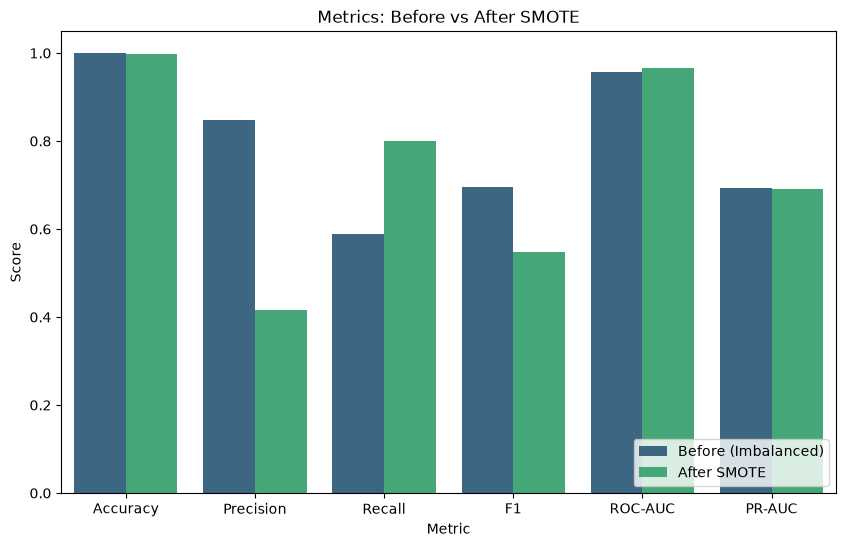

In [57]:
comparison = pd.DataFrame([metrics_before, metrics_after])
print(comparison.round(4))

# Visual comparison
comparison_melted = comparison.melt(id_vars='Approach', var_name='Metric', value_name='Score')
sns.barplot(data=comparison_melted, x='Metric', y='Score', hue='Approach', palette='viridis')
plt.title('Metrics: Before vs After SMOTE')
plt.ylim(0, 1.05)
plt.legend(loc='lower right')
plt.show()

### 9. Confusion Matrices

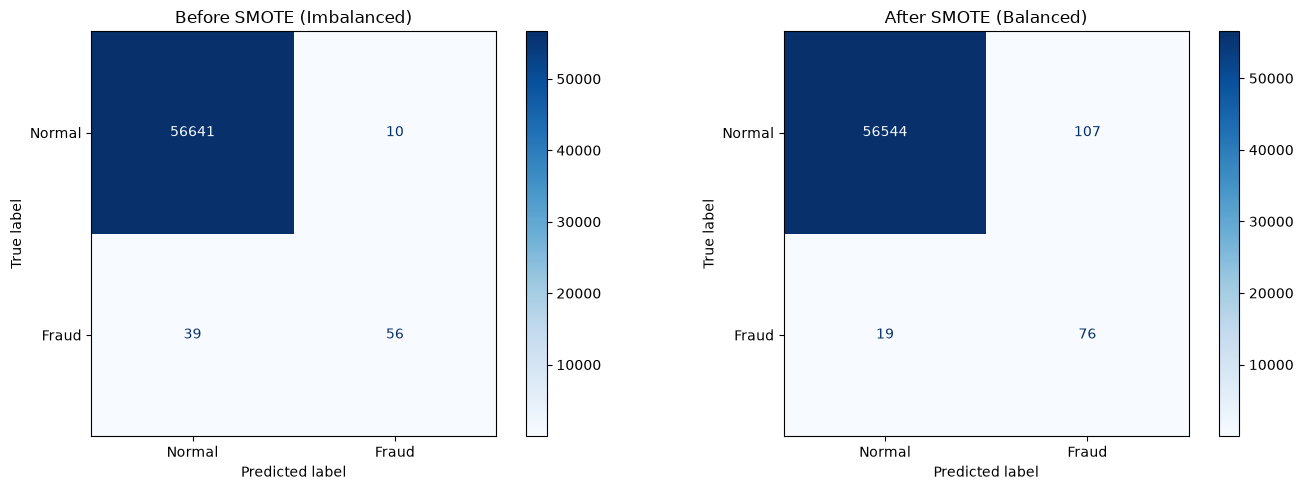

In [58]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_before, ax=axes[0], 
                                        cmap='Blues', display_labels=['Normal', 'Fraud'])
axes[0].set_title('Before SMOTE (Imbalanced)')

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_after, ax=axes[1], 
                                        cmap='Blues', display_labels=['Normal', 'Fraud'])
axes[1].set_title('After SMOTE (Balanced)')

plt.tight_layout()
plt.show()

## Summary
### Why Accuracy Is Misleading for Imbalanced Data

Only about 0.17% of transactions in this dataset are fraudulent. Therefore, a model could predict every transaction as normal and still achieve very high accuracy, while detecting no fraud at all. For this reason, accuracy should not be used as the main evaluation metric.

The SMOTE model achieved an accuracy of 99.78%, a fraud recall of 80.00%, and a fraud precision of 41.53%. This means the model successfully detects 80% of fraudulent transactions, while approximately 42% of transactions flagged as fraud are truly fraudulent.

The model also achieved a ROC-AUC score of 0.9670 and a PR-AUC score of 0.6912, showing strong ability to distinguish between normal and fraudulent transactions. Overall, recall, precision, F1-score, PR-AUC, and the confusion matrix provide a more reliable evaluation of fraud detection performance than accuracy alone.